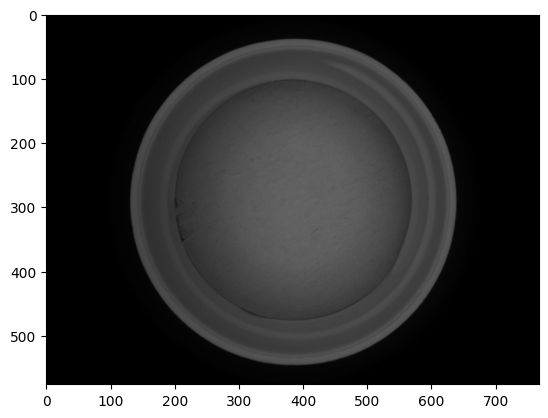

CAP OUTLINE - center: x=  385.5  y=  291.5  , radius=  254.0


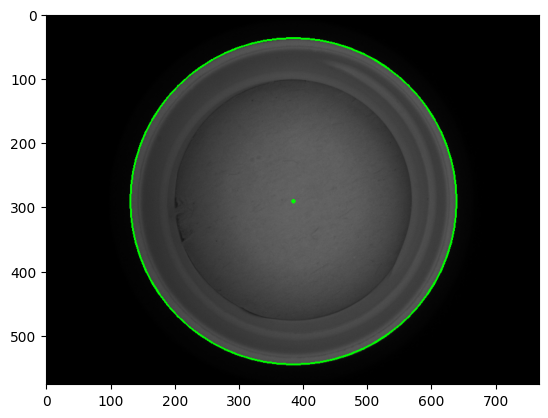

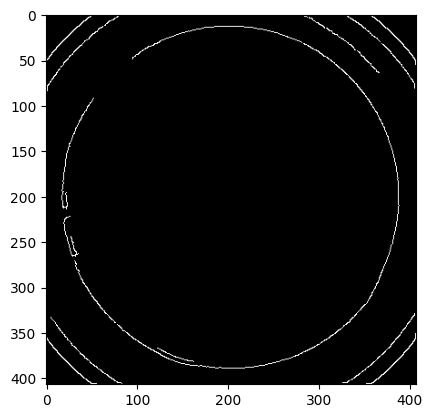

NO DEFECTS
LINER - center (in roi pic): x=  199.5  y=  201.5  - center (in full pic): x=  381.5  y=  289.5  , radius=  188.3


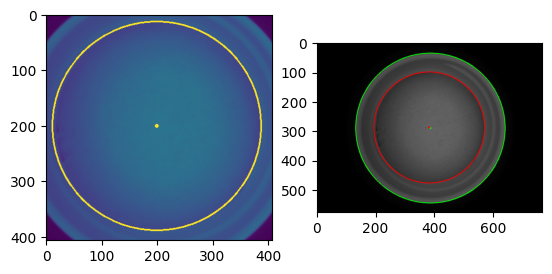

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_16.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_03.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''
######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########
#img_blur = cv2.GaussianBlur(img,(7,7),0)
img_blur = cv2.bilateralFilter(img,7,50,75)
circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi) (per il canny "integrato") - + alta mi trova solo il cerchio esterno
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
'''for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
plt.imshow(img_color)
plt.show()

#### ROI OF INSIDE THE CAP
offset = ((radius/math.sqrt(2))+radius)/2 # half way
offset = radius*0.8 # accazzodicane ##################################
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)  

img_roi=img_blur[y_min:y_max,x_min:x_max]
img_roi_show=img_roi.copy()



########## TASK 1.2 : identifica rotture liner

edges = cv2.Canny(img_roi,15,30,apertureSize = 3)
#edges = cv2.Canny(img_roi,10,30,apertureSize = 3) #VERY NICE
plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
plt.show() 

lines = cv2.HoughLines(edges,1,np.pi/180,70)
if lines is not None and len(lines) > 0:
    #
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        print("LINE: (",x0,",",y0,") - theta= ",theta," - rho: ",rho)
        cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.line(img_color, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2)
        
    '''
    rho, theta = lines[0][0] 
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    
    cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.line(img_color, (x1+x_min, y1+y_min), (x2+x_min, y2+y_min), (0, 0, 255), 2)

    '''
    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_roi_show)
    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.show()

    # PROVARE A FARE LA MEDIA DELLE LINEE CHE TROVA PER AVERNE SOLO UNA

    #### funziona bene con tutte c'è solo da capire come fare il rettangolo
else: 
    print("NO DEFECTS")

'''# houghlinesP : fa le linee "limitate" non infinite ma è peggio a prendere le linee complete perchè sono un po' stortine
linesP = cv2.HoughLinesP(edges,1,np.pi/180,60,minLineLength=50,maxLineGap=60)
#linesP = cv2.HoughLinesP(edges,1,np.pi/180,50,minLineLength=50,maxLineGap=58) # perfetta per d17

if linesP is not None and len(linesP) > 0:
    #
    for line in linesP:
        x1,y1,x2,y2= line[0]
        cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
  

    #x1,y1,x2,y2 = linesP[0][0] 
    #cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
   
    plt.figure()
    plt.imshow(img_color)
    plt.show()
'''






##### TASK 1.3: missing liner
'''
fare region of interest nel cerchio piccolo (si può fare circolare)
fare la avg lightness di altre immagini e trovare il valore medio più diffuso e se è più chiara allora è senza liner  
'''


######## TASK 2:  Outline the cap by generating a circle that fits the cap mouth 
circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=40,param2=60) # d_18 ne trova 3 ma il primo è quello giusto
#circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 45,param1=40,param2=60) # ALL OK EXCEPT G_04 if keep "half way" ROI
#cerchiamo il cerchio interno nella roi e poi per visualizzarlo gli diamo l'offset per ritrovarlo nell'immagine grande ((0,0) in img_roi = (x_min,y_min) in img "full")
# !!!!!!!!!!!11 d_31 questa non la trova (che ci sta che sia così)
if circles_in is not None and len(circles_in) > 0:

    #print(circles, circles.shape)
    for c in circles_in[0,:] : 
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(c[0]),int(c[1])),int(2),color=(255,0, 0),thickness=2)
        cv2.circle(img_color,(int(c[0])+x_min,int(c[1])+y_min),int(c[2]),color=(255, 0, 0),thickness=2)
        cv2.circle(img_color,(int(c[0])+x_min,int(c[1])+y_min),int(2),color=(255,0, 0),thickness=2)
        print("LINER - center (in roi pic): x= ", c[0]," y= ",c[1]," - center (in full pic): x= ", c[0]+x_min," y= ",c[1]+y_min," , radius= ",c[2])

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_roi_show)
    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.show()
else : 
    print("NO LINER")

